# Chapter 2: How much does a curve curve?

Source orientation: Pressley, printed pages 29-54; PDF pages 38-63; sections 2.1-2.3. The source is used here only to orient the concepts and sequence. The prose, code, diagrams, data, and checks in this notebook are original.

## Chapter Goal

Make curvature and torsion observable. By the end, a curve is no longer just a plotted trace: it carries a speed, a tangent, a normal, a turning rate, osculating circles, a binormal, and a Frenet-Serret frame whose residuals can be tested.

## Computational Translation Guide

| Book object | Computational object | What we inspect |
| --- | --- | --- |
| Unit-speed curvature | `norm(dT/ds)` or `norm(gamma''(s))` | second-order departure from a tangent line |
| Curvature in an arbitrary parameter | `norm(gamma' x gamma'') / norm(gamma')**3` | the same geometric curvature after speed is divided out |
| Signed curvature | `det(gamma', gamma'') / norm(gamma')**3` | whether the tangent turns counterclockwise or clockwise |
| Turning angle | `unwrap(arctan2(T_y, T_x))` | `d phi / ds = kappa_s` and total turn for closed curves |
| Osculating circle | center `gamma + n_s / kappa_s`, radius `1/abs(kappa_s)` | best local circle and its moving center, the evolute |
| Torsion | `(gamma' x gamma'') dot gamma''' / norm(gamma' x gamma'')**2` | how the curve leaves a fixed plane |
| Frenet-Serret equations | residuals for `T'`, `N'`, `B'` in the frame basis | skew-symmetric frame bookkeeping |

## Route

1. Build curvature from tangent-line deviation and verify the arbitrary-parameter formula.
2. Add orientation: signed curvature is tangent-angle velocity.
3. Turn curvature into geometry: osculating circles and evolutes.
4. Move to space curves: helix curvature, torsion, and 3D frames.
5. Check Frenet-Serret equations numerically and symbolically.
6. Design curves from prescribed signed curvature in the applied lab.


In [1]:
from pathlib import Path
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json

UNIT = "chapter-02"
CHAPTER_NOTEBOOK = BOOK_ROOT / "chapter-02-how-much-does-a-curve-curve" / "02-how-much-does-a-curve-curve.ipynb"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIG_DIR = UNIT_ARTIFACT_ROOT / "figures"
HTML_DIR = UNIT_ARTIFACT_ROOT / "interactive"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
for directory in (FIG_DIR, HTML_DIR, CHECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2f3542",
    "axes.labelcolor": "#2f3542",
    "xtick.color": "#2f3542",
    "ytick.color": "#2f3542",
    "font.size": 10,
})

PALETTE = {
    "blue": "#2f6fbb",
    "red": "#c44e52",
    "green": "#2e8b57",
    "gold": "#c49a3a",
    "purple": "#6f5fb8",
    "gray": "#6c7480",
    "light": "#e7ebf0",
    "ink": "#222831",
}


## Standalone Reading Guide

This chapter turns the vague question of how sharply a curve bends into computable invariants. Curvature measures how fast the unit tangent turns with respect to arc length, so the first habit is to separate geometric bending from the speed of a chosen parametrization. The notebook therefore compares unit-speed formulas with arbitrary-parameter formulas and checks that the same curve gives the same curvature after reparametrization.

The signed-curvature and turning visuals should be read as orientation tests. In the plane, the sign records whether the tangent turns left or right, and the total turning records global behavior around a closed curve. Osculating circles then convert curvature into a local best-fitting circle, while the evolute traces the centers of those circles. For space curves, torsion joins curvature: curvature says the curve leaves its tangent line, and torsion says the osculating plane itself twists.

The Frenet-frame artifact ties those ideas together. The moving frame is trusted only when the numerical and symbolic checks agree with the Frenet-Serret equations. The applied reconstruction lab runs the chapter backward: prescribe signed curvature, integrate the turning angle, and inspect the curve that results. That makes curvature a generator of shape, not just a measurement after the fact.


In [2]:
def as_points(points, dim=None):
    arr = np.asarray(points, dtype=float)
    if arr.ndim != 2:
        raise ValueError("points must be a two-dimensional array")
    if dim is not None and arr.shape[1] != dim:
        raise ValueError(f"expected points in R^{dim}")
    return arr


def derivative(values, parameter):
    values = np.asarray(values, dtype=float)
    parameter = np.asarray(parameter, dtype=float)
    return np.gradient(values, parameter, axis=0, edge_order=2)


def normalize(vectors, eps=1e-12):
    vectors = np.asarray(vectors, dtype=float)
    norms = np.linalg.norm(vectors, axis=-1, keepdims=True)
    return vectors / np.maximum(norms, eps)


def speed(points, parameter):
    return np.linalg.norm(derivative(as_points(points), parameter), axis=1)


def cumulative_trapezoid(values, x):
    values = np.asarray(values, dtype=float)
    x = np.asarray(x, dtype=float)
    increments = 0.5 * (values[1:] + values[:-1]) * np.diff(x)
    return np.concatenate([[0.0], np.cumsum(increments)])


def signed_curvature_2d(points, parameter):
    pts = as_points(points, 2)
    d1 = derivative(pts, parameter)
    d2 = derivative(d1, parameter)
    det = d1[:, 0] * d2[:, 1] - d1[:, 1] * d2[:, 0]
    denom = np.linalg.norm(d1, axis=1) ** 3
    return np.divide(det, denom, out=np.zeros_like(det), where=denom > 1e-12)


def curvature_3d(points, parameter):
    pts = as_points(points, 3)
    d1 = derivative(pts, parameter)
    d2 = derivative(d1, parameter)
    numerator = np.linalg.norm(np.cross(d1, d2), axis=1)
    denom = np.linalg.norm(d1, axis=1) ** 3
    return np.divide(numerator, denom, out=np.zeros_like(numerator), where=denom > 1e-12)


def torsion_3d(points, parameter):
    pts = as_points(points, 3)
    d1 = derivative(pts, parameter)
    d2 = derivative(d1, parameter)
    d3 = derivative(d2, parameter)
    cross = np.cross(d1, d2)
    denom = np.linalg.norm(cross, axis=1) ** 2
    numerator = np.einsum("ij,ij->i", cross, d3)
    return np.divide(numerator, denom, out=np.zeros_like(numerator), where=denom > 1e-12)


def tangent_2d(points, parameter):
    return normalize(derivative(as_points(points, 2), parameter))


def signed_normal_2d(tangent):
    tangent = np.asarray(tangent, dtype=float)
    return np.column_stack([-tangent[:, 1], tangent[:, 0]])


def turning_angle(points, parameter):
    tangent = tangent_2d(points, parameter)
    return np.unwrap(np.arctan2(tangent[:, 1], tangent[:, 0]))


def circle_center_three_points(p1, p2, p3):
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)
    A = np.array([
        [2.0 * (p2[0] - p1[0]), 2.0 * (p2[1] - p1[1])],
        [2.0 * (p3[0] - p1[0]), 2.0 * (p3[1] - p1[1])],
    ])
    b = np.array([
        p2[0] ** 2 + p2[1] ** 2 - p1[0] ** 2 - p1[1] ** 2,
        p3[0] ** 2 + p3[1] ** 2 - p1[0] ** 2 - p1[1] ** 2,
    ])
    return np.linalg.solve(A, b)


def line_collection_by_value(x, y, values, cmap="coolwarm", linewidth=2.4):
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(segments, cmap=cmap, linewidth=linewidth)
    collection.set_array(0.5 * (values[:-1] + values[1:]))
    return collection


def save_figure(fig, filename, *, dpi=170):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return path


def write_check(filename, payload):
    return save_json(payload, UNIT, "checks", filename, root=ARTIFACT_ROOT)


def relative_to_book(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


In [3]:
source_span = {
    "title": "How much does a curve curve?",
    "book": "Andrew Pressley, Elementary Differential Geometry, Second Edition",
    "printed_pages": "29-54",
    "pdf_pages": "38-63",
    "sections": "2.1-2.3",
    "orientation_only": True,
}

visual_storyboard = {
    "chapter_goal": "Make curvature, signed curvature, osculating circles, torsion, and Frenet-Serret frames visible and testable.",
    "source_span_read": source_span,
    "library_routing_table": [
        {"concept": "2D tangent deviation, signed curvature, evolute", "representation": "labeled static diagrams", "library": "Matplotlib", "why": "2D incidence, orientation, and local-circle constructions need durable annotated figures."},
        {"concept": "arbitrary-parameter and helix formulas", "representation": "exact formula checks", "library": "SymPy", "why": "the key formulas simplify exactly before numerical plotting."},
        {"concept": "space-curve frame inspection", "representation": "interactive 3D traces and frame arrows", "library": "Plotly", "why": "torsion and binormal rotation are spatial and benefit from rotation."},
        {"concept": "applied curve reconstruction", "representation": "tables plus plotted reconstructed curves", "library": "NumPy/Pandas/Matplotlib", "why": "the construction is an integral recipe from signed curvature to a curve."},
    ],
    "visual_sequence": [
        {"artifact": "figures/curvature-chapter-02.png", "concept": "unit-speed curvature and parameter-invariant curvature", "inspection_target": "the tangent-line deviation scales quadratically and circle curvature stays fixed under reparameterization", "validation": "symbolic and numeric curvature residuals"},
        {"artifact": "figures/signed-curvature-turning.png", "concept": "signed curvature and tangent turning", "inspection_target": "sign changes in curvature match clockwise/counterclockwise tangent motion", "validation": "d phi/ds residual and closed-curve turning number"},
        {"artifact": "figures/osculating-chapter-02.png", "concept": "osculating circles and evolute", "inspection_target": "centers of curvature trace the evolute and nearby three-point circles converge", "validation": "center convergence residuals"},
        {"artifact": "figures/torsion-chapter-02.png", "concept": "helix curvature and torsion", "inspection_target": "pitch changes torsion while the plane-circle case has zero torsion", "validation": "helix formula residuals"},
        {"artifact": "figures/frame-chapter-02.png", "concept": "Frenet-Serret frame snapshots", "inspection_target": "T, N, B remain orthonormal and right-handed", "validation": "Gram matrix and Frenet-Serret residuals"},
        {"artifact": "interactive/helix-frenet-frame-torsion.html", "concept": "rotatable helix frame", "inspection_target": "binormal movement out of the osculating plane", "validation": "same helix residual payload as the static plot"},
        {"artifact": "figures/curvature-reconstruction-lab.png", "concept": "curves designed from signed curvature", "inspection_target": "integrating kappa_s controls tangent angle first, position second", "validation": "speed and curvature reconstruction errors"},
    ],
}

source_path = write_check("source-span.json", source_span)
storyboard_path = write_check("visual-storyboard.json", visual_storyboard)
pd.DataFrame(visual_storyboard["visual_sequence"])


,artifact,concept,inspection_target,validation
0,figures/curvature-chapter-02.png,unit-speed curvature and parameter-invariant c...,the tangent-line deviation scales quadraticall...,symbolic and numeric curvature residuals
1,figures/signed-curvature-turning.png,signed curvature and tangent turning,sign changes in curvature match clockwise/coun...,d phi/ds residual and closed-curve turning number
2,figures/osculating-chapter-02.png,osculating circles and evolute,centers of curvature trace the evolute and nea...,center convergence residuals
3,figures/torsion-chapter-02.png,helix curvature and torsion,pitch changes torsion while the plane-circle c...,helix formula residuals
4,figures/frame-chapter-02.png,Frenet-Serret frame snapshots,"T, N, B remain orthonormal and right-handed",Gram matrix and Frenet-Serret residuals
5,interactive/helix-frenet-frame-torsion.html,rotatable helix frame,binormal movement out of the osculating plane,same helix residual payload as the static plot
6,figures/curvature-reconstruction-lab.png,curves designed from signed curvature,integrating kappa_s controls tangent angle fir...,speed and curvature reconstruction errors


## 2.1 Curvature As Second-Order Departure

For a unit-speed curve, the tangent vector already has length one, so its derivative measures only change of direction. That makes curvature `kappa = ||dT/ds|| = ||gamma''(s)||`. If a curve is not unit-speed, the parameter may make the same geometric trace move faster or slower. The cross-product formula removes that speed and leaves the same curvature attached to the underlying curve.

The figure below has two jobs. The left panel turns the Taylor expansion into a picture: the normal departure from the tangent line is quadratic in the small arc increment. The right panel computes curvature for the same circle with two different speeds and shows that the curvature remains the reciprocal radius.


In [4]:
u, R, a_sym, b_sym = sp.symbols("u R a b", positive=True)

theta = u**3
circle = sp.Matrix([R * sp.cos(theta), R * sp.sin(theta)])
d1 = circle.diff(u)
d2 = d1.diff(u)
det = sp.simplify(d1[0] * d2[1] - d1[1] * d2[0])
speed_sq = sp.simplify(d1.dot(d1))
circle_kappa = sp.simplify(det / speed_sq ** sp.Rational(3, 2))

th = sp.symbols("theta", real=True)
helix = sp.Matrix([a_sym * sp.cos(th), a_sym * sp.sin(th), b_sym * th])
h1 = helix.diff(th)
h2 = h1.diff(th)
h3 = h2.diff(th)
h_cross = sp.Matrix([h1[1]*h2[2] - h1[2]*h2[1], h1[2]*h2[0] - h1[0]*h2[2], h1[0]*h2[1] - h1[1]*h2[0]])
helix_kappa_symbolic = sp.simplify(sp.sqrt(h_cross.dot(h_cross)) / sp.sqrt(h1.dot(h1))**3)
helix_tau_symbolic = sp.simplify(h_cross.dot(h3) / h_cross.dot(h_cross))

symbolic_checks = {
    "circle_reparameterization": {
        "parameter": "theta = u**3 with u > 0",
        "determinant": str(det),
        "speed_squared": str(speed_sq),
        "curvature": str(circle_kappa),
        "equals_1_over_R": bool(sp.simplify(circle_kappa - 1 / R) == 0),
    },
    "helix_formulas": {
        "curvature": str(helix_kappa_symbolic),
        "torsion": str(helix_tau_symbolic),
        "curvature_expected": "a/(a**2 + b**2)",
        "torsion_expected": "b/(a**2 + b**2)",
        "curvature_matches": bool(sp.simplify(helix_kappa_symbolic - a_sym / (a_sym**2 + b_sym**2)) == 0),
        "torsion_matches": bool(sp.simplify(helix_tau_symbolic - b_sym / (a_sym**2 + b_sym**2)) == 0),
    },
}
symbolic_path = write_check("curvature-formula-symbolic.json", symbolic_checks)
symbolic_checks


{'circle_reparameterization': {'parameter': 'theta = u**3 with u > 0',
  'determinant': '27*R**2*u**6',
  'speed_squared': '9*R**2*u**4',
  'curvature': '1/R',
  'equals_1_over_R': True},
 'helix_formulas': {'curvature': 'a/(a**2 + b**2)',
  'torsion': 'b/(a**2 + b**2)',
  'curvature_expected': 'a/(a**2 + b**2)',
  'torsion_expected': 'b/(a**2 + b**2)',
  'curvature_matches': True,
  'torsion_matches': True}}

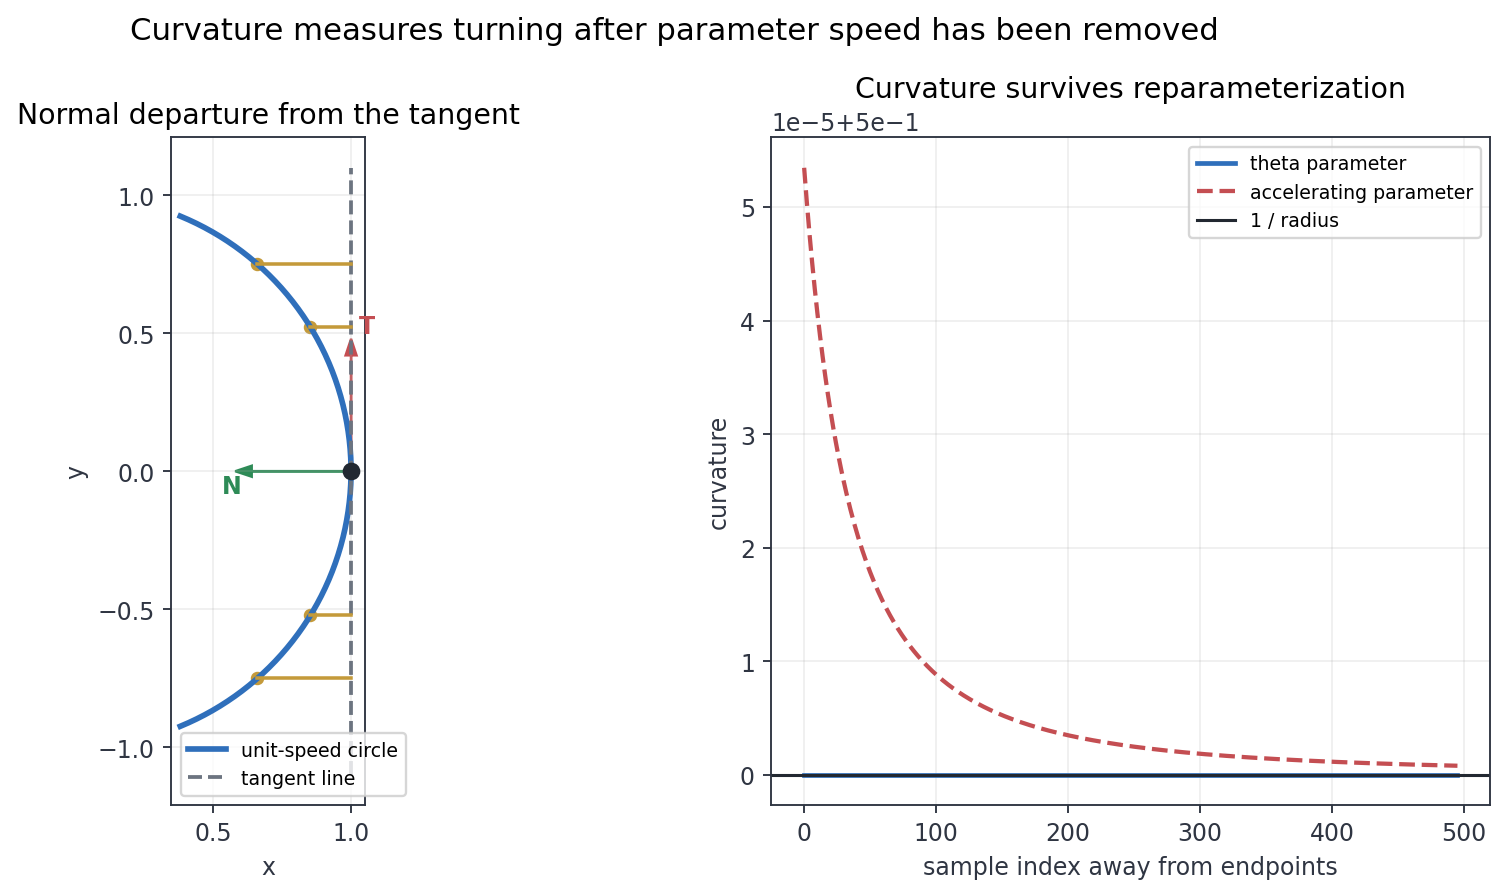

{'unit_circle_deviation_model_max_error': 0.021233145884982152,
 'circle_radius': 2.0,
 'plain_parameter_curvature_mean': 0.4999999999999999,
 'reparameterized_curvature_mean': 0.5000065301863785,
 'max_error_plain_from_1_over_R': 5.323519403077626e-13,
 'max_error_reparameterized_from_1_over_R': 5.3453666893577e-05}

In [5]:
s = np.linspace(-1.18, 1.18, 220)
circle_pts = np.column_stack([np.cos(s), np.sin(s)])
base = np.array([1.0, 0.0])
tangent_line_y = np.linspace(-1.1, 1.1, 120)
tangent_line_x = np.ones_like(tangent_line_y)
probe_s = np.array([-0.85, -0.55, 0.55, 0.85])
probe_pts = np.column_stack([np.cos(probe_s), np.sin(probe_s)])
normal_deviation = 1.0 - np.cos(probe_s)
quadratic_model = 0.5 * probe_s**2

radius = 2.0
p = np.linspace(0.02, 2 * np.pi - 0.02, 520)
plain = np.column_stack([radius * np.cos(p), radius * np.sin(p)])
fast_param = np.linspace(0.04, 2.5, 520)
angle_fast = 0.55 * fast_param**2 + 0.25 * fast_param
reparam = np.column_stack([radius * np.cos(angle_fast), radius * np.sin(angle_fast)])
plain_k = signed_curvature_2d(plain, p)
reparam_k = signed_curvature_2d(reparam, fast_param)
interior = slice(12, -12)
curvature_check = {
    "unit_circle_deviation_model_max_error": float(np.max(np.abs(normal_deviation - quadratic_model))),
    "circle_radius": radius,
    "plain_parameter_curvature_mean": float(np.mean(np.abs(plain_k[interior]))),
    "reparameterized_curvature_mean": float(np.mean(np.abs(reparam_k[interior]))),
    "max_error_plain_from_1_over_R": float(np.max(np.abs(np.abs(plain_k[interior]) - 1 / radius))),
    "max_error_reparameterized_from_1_over_R": float(np.max(np.abs(np.abs(reparam_k[interior]) - 1 / radius))),
}
curvature_path_json = write_check("curvature-invariance-checks.json", curvature_check)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.1))
ax = axes[0]
ax.plot(circle_pts[:, 0], circle_pts[:, 1], color=PALETTE["blue"], lw=2.4, label="unit-speed circle")
ax.plot(tangent_line_x, tangent_line_y, color=PALETTE["gray"], lw=1.6, linestyle="--", label="tangent line")
ax.scatter([base[0]], [base[1]], color=PALETTE["ink"], s=42, zorder=4)
ax.arrow(base[0], base[1], 0.0, 0.48, head_width=0.04, color=PALETTE["red"], length_includes_head=True)
ax.arrow(base[0], base[1], -0.42, 0.0, head_width=0.04, color=PALETTE["green"], length_includes_head=True)
ax.text(base[0] + 0.03, base[1] + 0.5, "T", color=PALETTE["red"], weight="bold")
ax.text(base[0] - 0.47, base[1] - 0.08, "N", color=PALETTE["green"], weight="bold")
for pt in probe_pts:
    ax.plot([pt[0], 1.0], [pt[1], pt[1]], color=PALETTE["gold"], lw=1.5)
    ax.scatter([pt[0]], [pt[1]], color=PALETTE["gold"], s=22)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Normal departure from the tangent")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.2)

ax = axes[1]
sample = np.arange(len(plain_k[interior]))
ax.plot(sample, np.abs(plain_k[interior]), color=PALETTE["blue"], lw=2, label="theta parameter")
ax.plot(sample, np.abs(reparam_k[interior]), color=PALETTE["red"], lw=1.8, linestyle="--", label="accelerating parameter")
ax.axhline(1 / radius, color=PALETTE["ink"], lw=1.3, label="1 / radius")
ax.set_title("Curvature survives reparameterization")
ax.set_xlabel("sample index away from endpoints")
ax.set_ylabel("curvature")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.suptitle("Curvature measures turning after parameter speed has been removed", y=1.02, fontsize=13)
curvature_figure = save_figure(fig, "curvature-chapter-02.png")
display_artifact(curvature_figure, width=940)
curvature_check


## 2.2 Signed Curvature And Tangent Turning

A plane curve has a preferred signed normal once an orientation of the plane is chosen: rotate the unit tangent counterclockwise by 90 degrees. The signed curvature is the scalar multiplying that normal. The sign is not decorative; it records whether the tangent direction is rotating counterclockwise or clockwise as arc length increases.

The tangent angle `phi` is easiest to compute by unwrapping `atan2(T_y, T_x)`. Then `kappa_s = d phi / ds`. For a closed regular plane curve, the net change in `phi` is an integer multiple of `2 pi`; this is the total signed curvature.


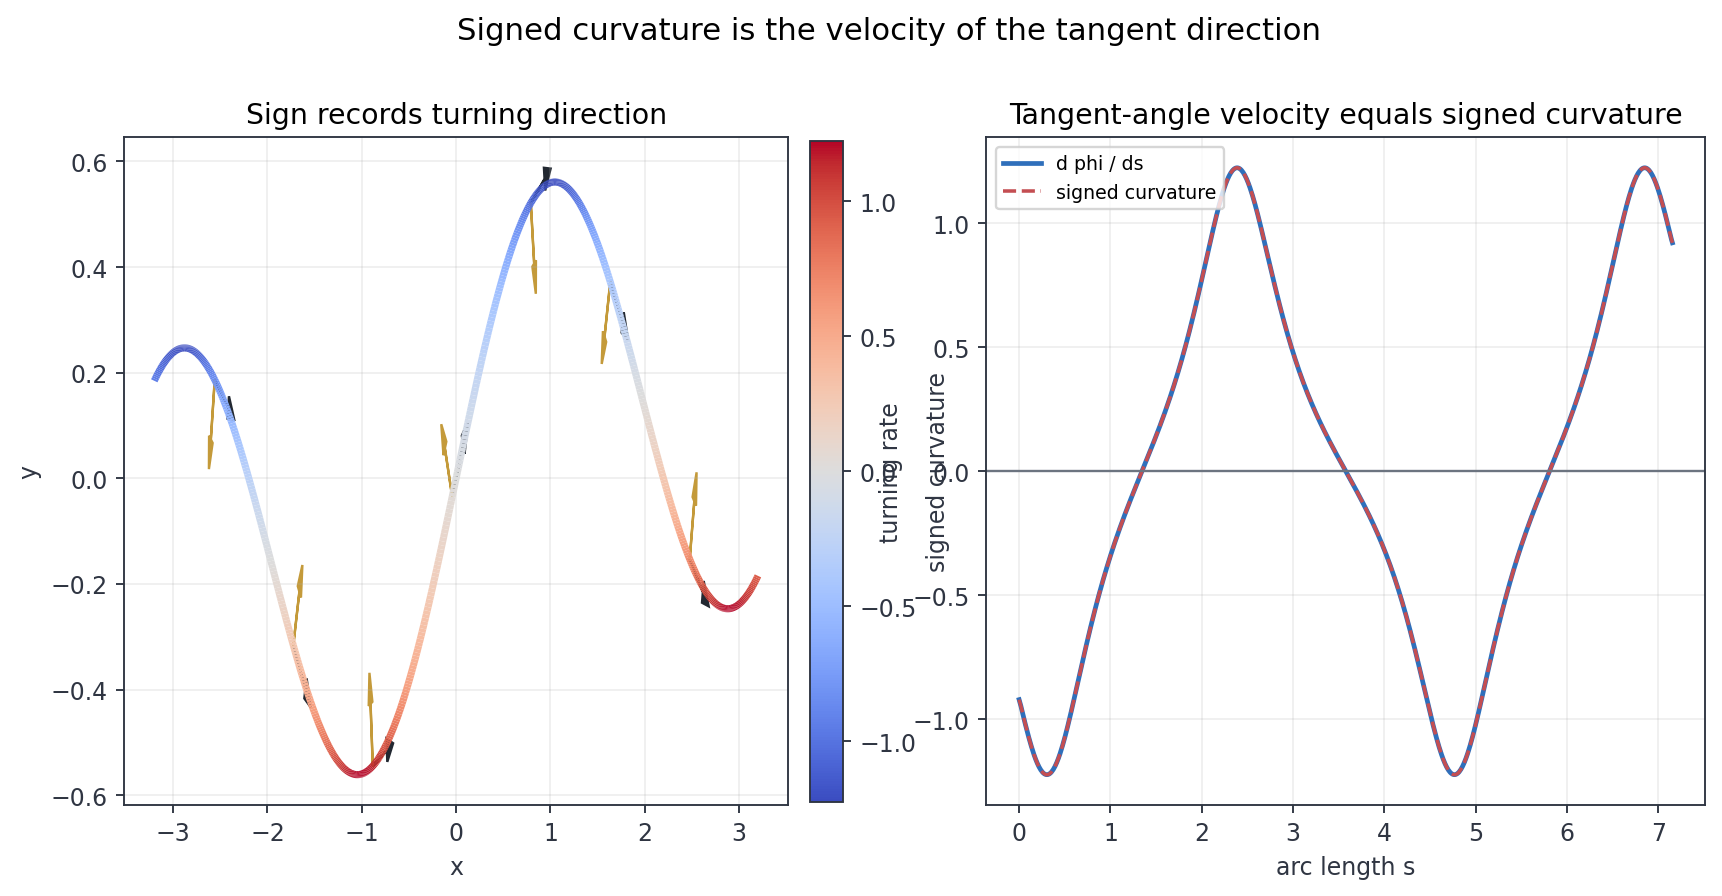

{'max_abs_dphi_ds_minus_signed_curvature': 9.017651552345463e-05,
 'mean_abs_dphi_ds_minus_signed_curvature': 4.0006249890693265e-05,
 'ellipse_turning_number': 0.9999999856129885,
 'ellipse_total_signed_curvature': 6.283164191895088,
 'ellipse_total_signed_curvature_over_2pi': 0.9999966393980972}

In [6]:
t = np.linspace(-3.2, 3.2, 700)
turn_curve = np.column_stack([t, 0.48 * np.sin(1.6 * t) + 0.08 * t])
turn_speed = speed(turn_curve, t)
turn_s = cumulative_trapezoid(turn_speed, t)
turn_k = signed_curvature_2d(turn_curve, t)
phi = turning_angle(turn_curve, t)
dphi_ds = np.gradient(phi, turn_s, edge_order=2)
turn_interior = slice(20, -20)
turn_residual = dphi_ds[turn_interior] - turn_k[turn_interior]

ellipse_t = np.linspace(0, 2 * np.pi, 1400, endpoint=False)
ellipse = np.column_stack([2.0 * np.cos(ellipse_t), 1.0 * np.sin(ellipse_t)])
ellipse_closed = np.vstack([ellipse, ellipse[0]])
ellipse_param_closed = np.append(ellipse_t, 2 * np.pi)
ellipse_phi = turning_angle(ellipse_closed, ellipse_param_closed)
ellipse_turning_number = (ellipse_phi[-1] - ellipse_phi[0]) / (2 * np.pi)
ellipse_k = signed_curvature_2d(ellipse_closed, ellipse_param_closed)
ellipse_speed = speed(ellipse_closed, ellipse_param_closed)
ellipse_total_signed = np.trapezoid(ellipse_k * ellipse_speed, ellipse_param_closed)

turning_check = {
    "max_abs_dphi_ds_minus_signed_curvature": float(np.max(np.abs(turn_residual))),
    "mean_abs_dphi_ds_minus_signed_curvature": float(np.mean(np.abs(turn_residual))),
    "ellipse_turning_number": float(ellipse_turning_number),
    "ellipse_total_signed_curvature": float(ellipse_total_signed),
    "ellipse_total_signed_curvature_over_2pi": float(ellipse_total_signed / (2 * np.pi)),
}
turning_path_json = write_check("signed-curvature-turning-checks.json", turning_check)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.1))
ax = axes[0]
lc = line_collection_by_value(turn_curve[:, 0], turn_curve[:, 1], turn_k, linewidth=3.0)
ax.add_collection(lc)
ax.autoscale()
cb = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.03)
cb.set_label("signed curvature")
T_turn = tangent_2d(turn_curve, t)
N_turn = signed_normal_2d(T_turn)
for idx in np.linspace(70, len(t) - 80, 7, dtype=int):
    p0 = turn_curve[idx]
    ax.arrow(p0[0], p0[1], 0.22 * T_turn[idx, 0], 0.22 * T_turn[idx, 1], head_width=0.045, color=PALETTE["ink"], length_includes_head=True)
    ax.arrow(p0[0], p0[1], 0.18 * np.sign(turn_k[idx]) * N_turn[idx, 0], 0.18 * np.sign(turn_k[idx]) * N_turn[idx, 1], head_width=0.04, color=PALETTE["gold"], length_includes_head=True)
ax.set_title("Sign records turning direction")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.2)

ax = axes[1]
ax.plot(turn_s, dphi_ds, color=PALETTE["blue"], lw=2, label="d phi / ds")
ax.plot(turn_s, turn_k, color=PALETTE["red"], lw=1.5, linestyle="--", label="signed curvature")
ax.axhline(0, color=PALETTE["gray"], lw=1)
ax.set_title("Tangent-angle velocity equals signed curvature")
ax.set_xlabel("arc length s")
ax.set_ylabel("turning rate")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.suptitle("Signed curvature is the velocity of the tangent direction", y=1.02, fontsize=13)
signed_figure = save_figure(fig, "signed-curvature-turning.png")
display_artifact(signed_figure, width=940)
turning_check


## Osculating Circles And Evolutes

Curvature also has a local best-circle interpretation. When `kappa_s` is nonzero, the center of curvature is

`epsilon = gamma + n_s / kappa_s`.

As the point moves along the curve, these centers trace the evolute. One diagnostic for the formula is to compare it with circles through three nearby points: as the spacing shrinks, the three-point circle center should converge to `epsilon`.


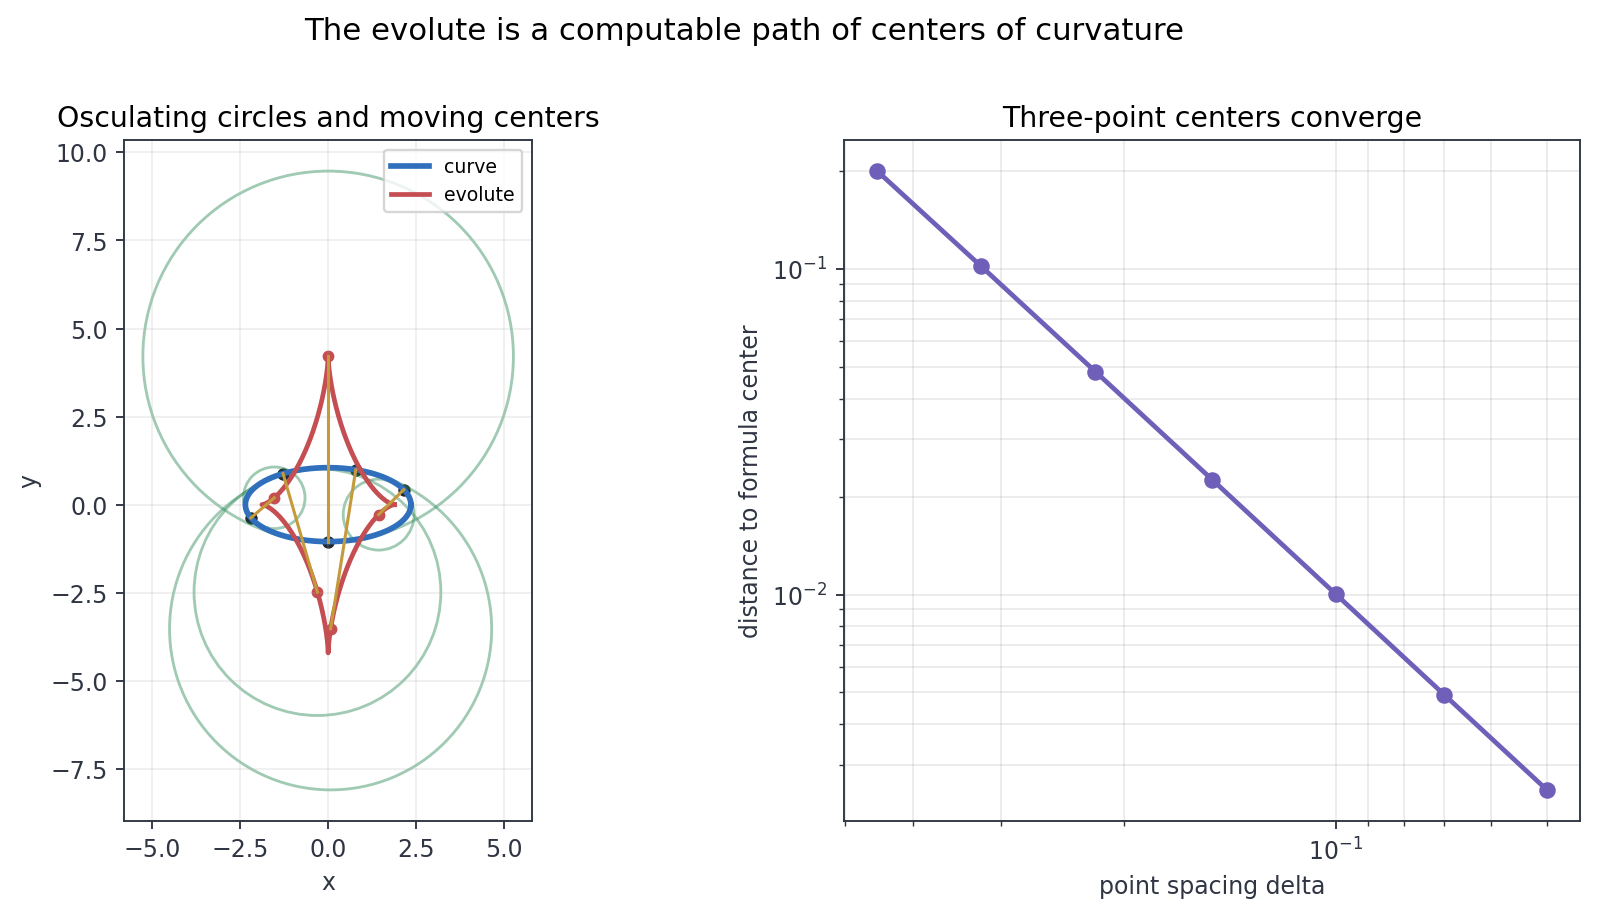

{'ellipse_min_abs_signed_curvature': 0.19013128112241998,
 'ellipse_max_radius_of_curvature': 5.259523809531001,
 'three_point_center_errors': [0.1999736113779548,
  0.10197168556858484,
  0.048415206538184194,
  0.022555728164765587,
  0.010035218815070614,
  0.004919347759514205,
  0.002510373363323381],
 'error_ratio_first_to_last': 79.65891221583783,
 'converges_as_delta_shrinks': True}

In [7]:
a_ell, b_ell = 2.35, 1.05
ell_t = np.linspace(0, 2 * np.pi, 1200, endpoint=False)
ell = np.column_stack([a_ell * np.cos(ell_t), b_ell * np.sin(ell_t)])
T_ell = tangent_2d(ell, ell_t)
N_ell = signed_normal_2d(T_ell)
k_ell = signed_curvature_2d(ell, ell_t)
radius_ell = np.divide(1.0, np.abs(k_ell), out=np.full_like(k_ell, np.nan), where=np.abs(k_ell) > 1e-10)
evolute = ell + N_ell / k_ell[:, None]

sample_indices = np.array([80, 235, 410, 670, 900])
base_index = 235
base_t = ell_t[base_index]
center_formula = evolute[base_index]
deltas = np.array([0.45, 0.32, 0.22, 0.15, 0.10, 0.07, 0.05])
center_errors = []
for delta in deltas:
    p_minus = np.array([a_ell * np.cos(base_t - delta), b_ell * np.sin(base_t - delta)])
    p_mid = np.array([a_ell * np.cos(base_t), b_ell * np.sin(base_t)])
    p_plus = np.array([a_ell * np.cos(base_t + delta), b_ell * np.sin(base_t + delta)])
    ctr = circle_center_three_points(p_minus, p_mid, p_plus)
    center_errors.append(float(np.linalg.norm(ctr - center_formula)))
center_errors = np.array(center_errors)

osculating_check = {
    "ellipse_min_abs_signed_curvature": float(np.min(np.abs(k_ell))),
    "ellipse_max_radius_of_curvature": float(np.nanmax(radius_ell)),
    "three_point_center_errors": [float(x) for x in center_errors],
    "error_ratio_first_to_last": float(center_errors[0] / center_errors[-1]),
    "converges_as_delta_shrinks": bool(center_errors[-1] < center_errors[0]),
}
osculating_path_json = write_check("osculating-evolute-checks.json", osculating_check)

fig, axes = plt.subplots(1, 2, figsize=(12.3, 5.2))
ax = axes[0]
ax.plot(ell[:, 0], ell[:, 1], color=PALETTE["blue"], lw=2.4, label="curve")
ax.plot(evolute[:, 0], evolute[:, 1], color=PALETTE["red"], lw=2, label="evolute")
for idx in sample_indices:
    ctr = evolute[idx]
    p0 = ell[idx]
    rad = np.linalg.norm(p0 - ctr)
    ax.add_patch(Circle(ctr, rad, fill=False, color=PALETTE["green"], alpha=0.45, lw=1.2))
    ax.plot([p0[0], ctr[0]], [p0[1], ctr[1]], color=PALETTE["gold"], lw=1.3)
    ax.scatter([p0[0]], [p0[1]], color=PALETTE["ink"], s=18)
    ax.scatter([ctr[0]], [ctr[1]], color=PALETTE["red"], s=16)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Osculating circles and moving centers")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

ax = axes[1]
ax.loglog(deltas, center_errors, marker="o", color=PALETTE["purple"], lw=2)
ax.invert_xaxis()
ax.set_title("Three-point centers converge")
ax.set_xlabel("point spacing delta")
ax.set_ylabel("distance to formula center")
ax.grid(alpha=0.25, which="both")
fig.suptitle("The evolute is a computable path of centers of curvature", y=1.02, fontsize=13)
osculating_figure = save_figure(fig, "osculating-chapter-02.png")
display_artifact(osculating_figure, width=940)
osculating_check


## 2.3 Space Curves And Torsion

In space, curvature alone does not determine the curve. A circle and a suitably pitched helix can share the same curvature while occupying space differently. Torsion measures the rotation of the binormal, or equivalently how the osculating plane changes.

For the circular helix `gamma(theta) = (a cos theta, a sin theta, b theta)`, exact calculation gives

`kappa = a / (a^2 + b^2)`, `tau = b / (a^2 + b^2)` when `a > 0`.

The static artifact compares the numerical formulas against those constants. The Plotly artifact is included because rotating the frame is the most direct way to see torsion as spatial frame motion.


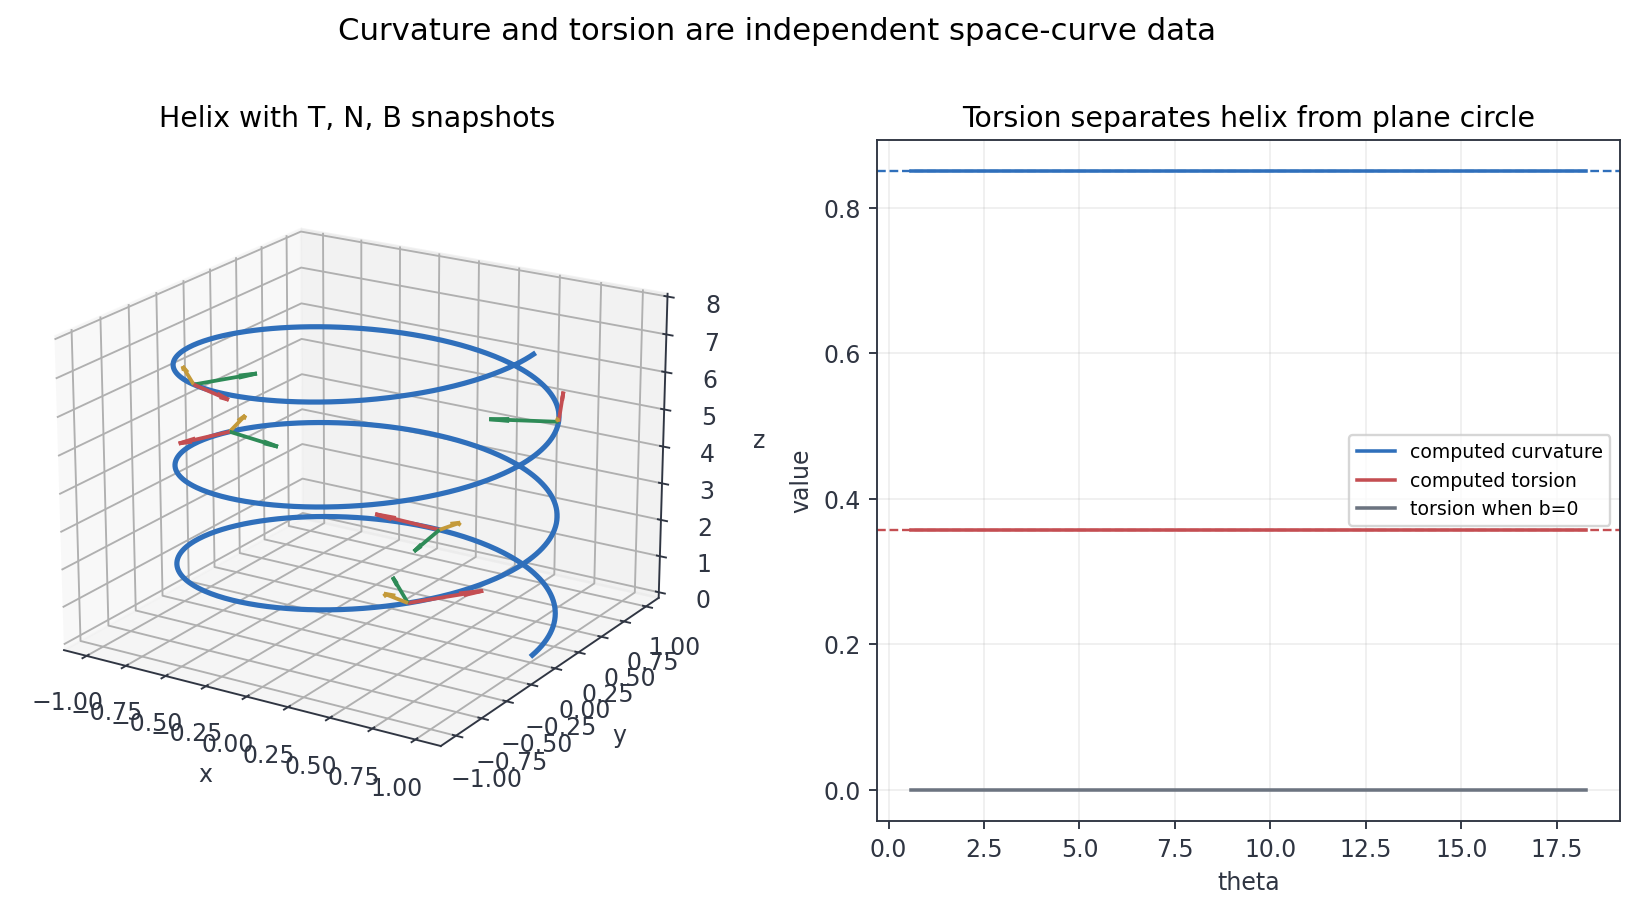

{'a': 1.0,
 'b': 0.42,
 'expected_curvature': 0.8500510030601837,
 'expected_torsion': 0.35702142128527714,
 'max_abs_curvature_residual': 1.5063174505058896e-05,
 'max_abs_torsion_residual': 1.4768528928787994e-05,
 'plane_circle_max_abs_torsion': 0.0}

In [8]:
def helix_points(theta, a=1.0, b=0.35):
    return np.column_stack([a * np.cos(theta), a * np.sin(theta), b * theta])


def helix_frame(theta, a=1.0, b=0.35):
    theta = np.asarray(theta, dtype=float)
    c = math.sqrt(a * a + b * b)
    T = np.column_stack([-a * np.sin(theta) / c, a * np.cos(theta) / c, np.full_like(theta, b / c)])
    N = np.column_stack([-np.cos(theta), -np.sin(theta), np.zeros_like(theta)])
    B = np.cross(T, N)
    return T, N, B


theta_grid = np.linspace(0.02, 6 * np.pi - 0.02, 1000)
helix_a = 1.0
helix_b = 0.42
helix_pts = helix_points(theta_grid, helix_a, helix_b)
helix_k = curvature_3d(helix_pts, theta_grid)
helix_tau = torsion_3d(helix_pts, theta_grid)
helix_k_expected = helix_a / (helix_a**2 + helix_b**2)
helix_tau_expected = helix_b / (helix_a**2 + helix_b**2)
plane_pts = helix_points(theta_grid, helix_a, 0.0)
plane_tau = torsion_3d(plane_pts, theta_grid)
helix_slice = slice(30, -30)

helix_check = {
    "a": helix_a,
    "b": helix_b,
    "expected_curvature": float(helix_k_expected),
    "expected_torsion": float(helix_tau_expected),
    "max_abs_curvature_residual": float(np.max(np.abs(helix_k[helix_slice] - helix_k_expected))),
    "max_abs_torsion_residual": float(np.max(np.abs(helix_tau[helix_slice] - helix_tau_expected))),
    "plane_circle_max_abs_torsion": float(np.max(np.abs(plane_tau[helix_slice]))),
}
helix_path_json = write_check("helix-torsion-checks.json", helix_check)

fig = plt.figure(figsize=(12.4, 5.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(helix_pts[:, 0], helix_pts[:, 1], helix_pts[:, 2], color=PALETTE["blue"], lw=2.2)
T_h, N_h, B_h = helix_frame(theta_grid, helix_a, helix_b)
for idx in np.linspace(90, len(theta_grid) - 110, 5, dtype=int):
    p0 = helix_pts[idx]
    ax.quiver(*p0, *(0.42 * T_h[idx]), color=PALETTE["red"], linewidth=1.6)
    ax.quiver(*p0, *(0.36 * N_h[idx]), color=PALETTE["green"], linewidth=1.6)
    ax.quiver(*p0, *(0.32 * B_h[idx]), color=PALETTE["gold"], linewidth=1.6)
ax.set_title("Helix with T, N, B snapshots")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=20, azim=-58)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(theta_grid[helix_slice], helix_k[helix_slice], color=PALETTE["blue"], label="computed curvature")
ax2.plot(theta_grid[helix_slice], helix_tau[helix_slice], color=PALETTE["red"], label="computed torsion")
ax2.axhline(helix_k_expected, color=PALETTE["blue"], linestyle="--", lw=1)
ax2.axhline(helix_tau_expected, color=PALETTE["red"], linestyle="--", lw=1)
ax2.plot(theta_grid[helix_slice], plane_tau[helix_slice], color=PALETTE["gray"], label="torsion when b=0")
ax2.set_title("Torsion separates helix from plane circle")
ax2.set_xlabel("theta")
ax2.set_ylabel("value")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)
fig.suptitle("Curvature and torsion are independent space-curve data", y=1.02, fontsize=13)
torsion_figure = save_figure(fig, "torsion-chapter-02.png")
display_artifact(torsion_figure, width=940)
helix_check


In [9]:
frame_indices = np.linspace(80, len(theta_grid) - 120, 9, dtype=int)
fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=helix_pts[:, 0], y=helix_pts[:, 1], z=helix_pts[:, 2],
    mode="lines", name="helix", line=dict(color="#2f6fbb", width=5)
))
colors = {"T": "#c44e52", "N": "#2e8b57", "B": "#c49a3a"}
for label, field, scale in [("T", T_h, 0.42), ("N", N_h, 0.36), ("B", B_h, 0.32)]:
    for idx in frame_indices:
        p0 = helix_pts[idx]
        p1 = p0 + scale * field[idx]
        first_for_label = bool(idx == frame_indices[0])
        fig3d.add_trace(go.Scatter3d(
            x=[p0[0], p1[0]], y=[p0[1], p1[1]], z=[p0[2], p1[2]],
            mode="lines", name=label if first_for_label else None,
            showlegend=first_for_label, line=dict(color=colors[label], width=5)
        ))
fig3d.update_layout(
    title="Circular helix with Frenet frame samples",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, t=48, b=0),
    legend=dict(orientation="h", yanchor="bottom", y=0.02, xanchor="left", x=0.02),
)
interactive_path = HTML_DIR / "helix-frenet-frame-torsion.html"
fig3d.write_html(interactive_path, include_plotlyjs="cdn", full_html=True)
assert_artifact(interactive_path, min_bytes=5000)
display_artifact(interactive_path, width="100%", height=560)
relative_to_book(interactive_path)


'artifacts/chapter-02/interactive/helix-frenet-frame-torsion.html'

## Frenet-Serret Frame Checks

The Frenet-Serret equations are not just three formulas to memorize. They say that the derivative of the moving frame is encoded by a skew-symmetric matrix:

`T' = kappa N`, `N' = -kappa T + tau B`, `B' = -tau N`.

Skew-symmetry is the computational reason orthonormality persists: differentiating dot products of frame vectors gives cancelling terms. The next cell checks this twice for the helix: with exact formulas and with sampled residuals.


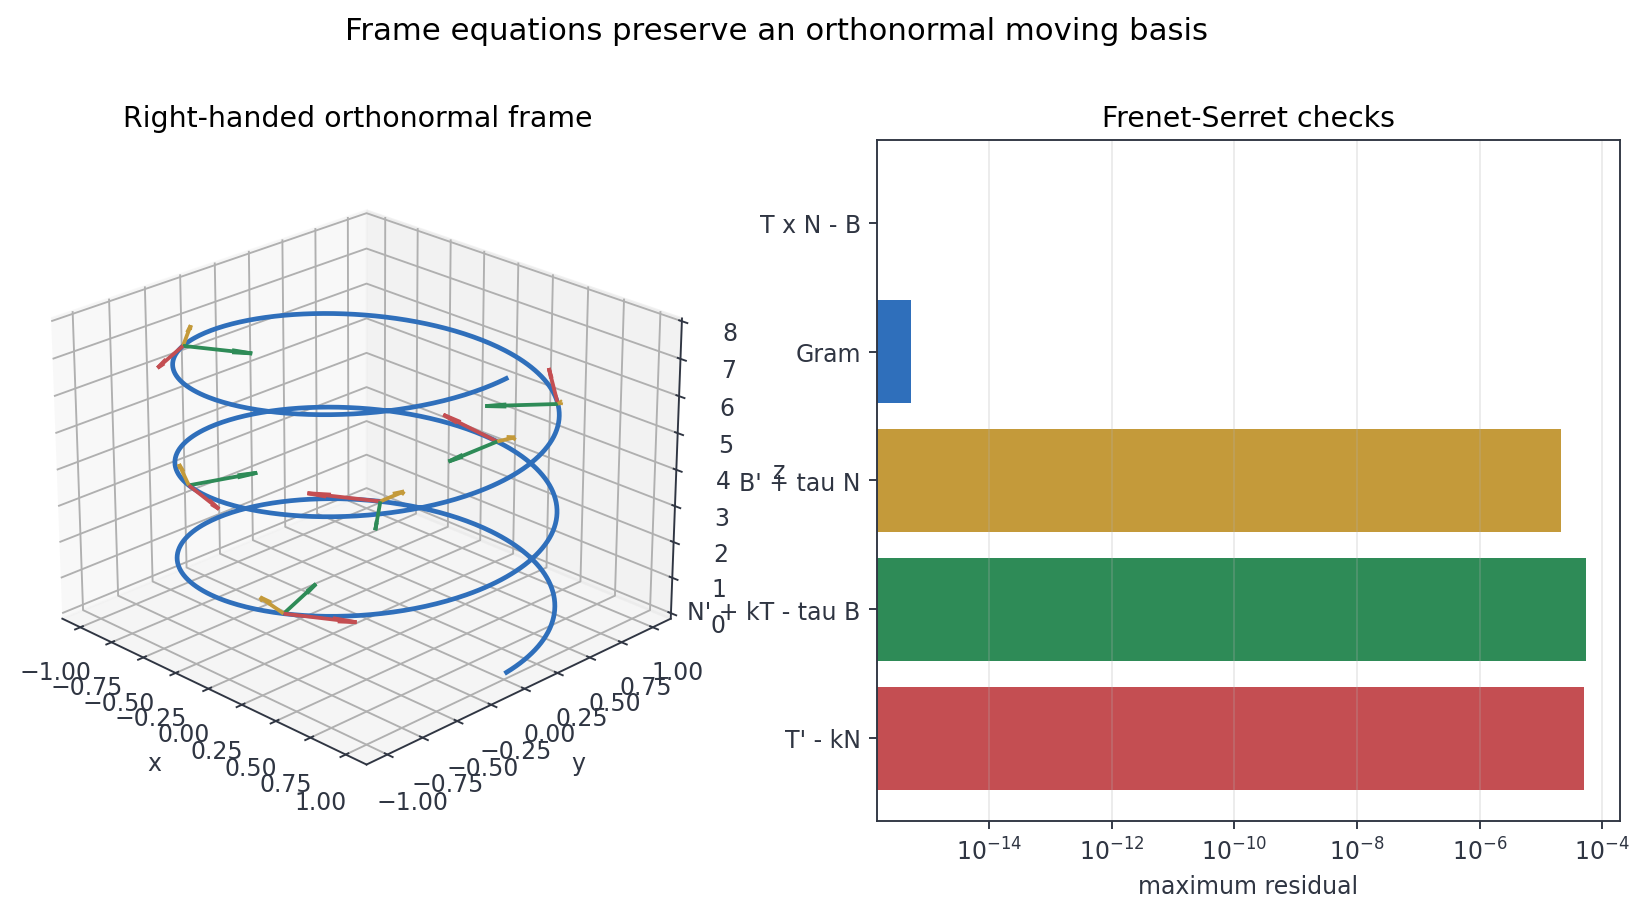

{'symbolic_residuals_zero': True,
 'skew_symmetric_matrix_residual_zero': True,
 'max_abs_T_equation_residual': 5.022409779407314e-05,
 'max_abs_N_equation_residual': 5.44740483429204e-05,
 'max_abs_B_equation_residual': 2.109412107294499e-05,
 'max_gram_residual': 5.322278831977913e-16,
 'max_orientation_residual': 0.0}

In [10]:
th_sym, aa, bb = sp.symbols("theta aa bb", positive=True)
cc = sp.sqrt(aa**2 + bb**2)
T_sym = sp.Matrix([-aa * sp.sin(th_sym) / cc, aa * sp.cos(th_sym) / cc, bb / cc])
N_sym = sp.Matrix([-sp.cos(th_sym), -sp.sin(th_sym), 0])
B_sym = T_sym.cross(N_sym)
kappa_sym = aa / (aa**2 + bb**2)
tau_sym = bb / (aa**2 + bb**2)


def ds_derivative(vec):
    return sp.simplify(vec.diff(th_sym) / cc)


sym_fs_residuals = [
    sp.simplify(ds_derivative(T_sym) - kappa_sym * N_sym),
    sp.simplify(ds_derivative(N_sym) + kappa_sym * T_sym - tau_sym * B_sym),
    sp.simplify(ds_derivative(B_sym) + tau_sym * N_sym),
]
fs_matrix = sp.Matrix([[0, kappa_sym, 0], [-kappa_sym, 0, tau_sym], [0, -tau_sym, 0]])
skew_residual = sp.simplify(fs_matrix + fs_matrix.T)

c_num = math.sqrt(helix_a**2 + helix_b**2)
dT_ds = derivative(T_h, theta_grid) / c_num
dN_ds = derivative(N_h, theta_grid) / c_num
dB_ds = derivative(B_h, theta_grid) / c_num
fs_r1 = dT_ds - helix_k_expected * N_h
fs_r2 = dN_ds + helix_k_expected * T_h - helix_tau_expected * B_h
fs_r3 = dB_ds + helix_tau_expected * N_h
gram_residuals = []
orientation_residuals = []
for T_vec, N_vec, B_vec in zip(T_h[helix_slice], N_h[helix_slice], B_h[helix_slice]):
    frame = np.vstack([T_vec, N_vec, B_vec])
    gram_residuals.append(np.linalg.norm(frame @ frame.T - np.eye(3), ord=np.inf))
    orientation_residuals.append(np.linalg.norm(np.cross(T_vec, N_vec) - B_vec))

fs_check = {
    "symbolic_residuals_zero": all(res == sp.zeros(3, 1) for res in sym_fs_residuals),
    "skew_symmetric_matrix_residual_zero": bool(skew_residual == sp.zeros(3, 3)),
    "max_abs_T_equation_residual": float(np.max(np.linalg.norm(fs_r1[helix_slice], axis=1))),
    "max_abs_N_equation_residual": float(np.max(np.linalg.norm(fs_r2[helix_slice], axis=1))),
    "max_abs_B_equation_residual": float(np.max(np.linalg.norm(fs_r3[helix_slice], axis=1))),
    "max_gram_residual": float(np.max(gram_residuals)),
    "max_orientation_residual": float(np.max(orientation_residuals)),
}
fs_path_json = write_check("frenet-serret-residuals.json", fs_check)

fig = plt.figure(figsize=(12.4, 5.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(helix_pts[:, 0], helix_pts[:, 1], helix_pts[:, 2], color=PALETTE["blue"], lw=2.0)
for idx in np.linspace(120, len(theta_grid) - 140, 6, dtype=int):
    p0 = helix_pts[idx]
    ax.quiver(*p0, *(0.44 * T_h[idx]), color=PALETTE["red"], linewidth=1.6)
    ax.quiver(*p0, *(0.38 * N_h[idx]), color=PALETTE["green"], linewidth=1.6)
    ax.quiver(*p0, *(0.34 * B_h[idx]), color=PALETTE["gold"], linewidth=1.6)
ax.set_title("Right-handed orthonormal frame")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=24, azim=-45)

ax2 = fig.add_subplot(1, 2, 2)
residual_names = ["T' - kN", "N' + kT - tau B", "B' + tau N", "Gram", "T x N - B"]
residual_values = [
    fs_check["max_abs_T_equation_residual"],
    fs_check["max_abs_N_equation_residual"],
    fs_check["max_abs_B_equation_residual"],
    fs_check["max_gram_residual"],
    fs_check["max_orientation_residual"],
]
ax2.barh(residual_names, residual_values, color=[PALETTE["red"], PALETTE["green"], PALETTE["gold"], PALETTE["blue"], PALETTE["purple"]])
ax2.set_xscale("log")
ax2.set_xlabel("maximum residual")
ax2.set_title("Frenet-Serret checks")
ax2.grid(axis="x", alpha=0.25)
fig.suptitle("Frame equations preserve an orthonormal moving basis", y=1.02, fontsize=13)
frame_figure = save_figure(fig, "frame-chapter-02.png")
display_artifact(frame_figure, width=940)
fs_check


## Applied Lab: Design A Plane Curve From Signed Curvature

The plane-curve existence theorem can be treated as an algorithm. Choose a smooth function `k(s)`. Integrate once to get the tangent angle `phi(s) = integral k(s) ds`. Integrate the unit tangent `(cos phi, sin phi)` to get the curve. This lab compares three inputs: constant signed curvature, linear signed curvature, and a wavy signed curvature.

The main check is that the reconstructed curve has speed one and that its measured signed curvature follows the prescribed function away from numerical endpoints.


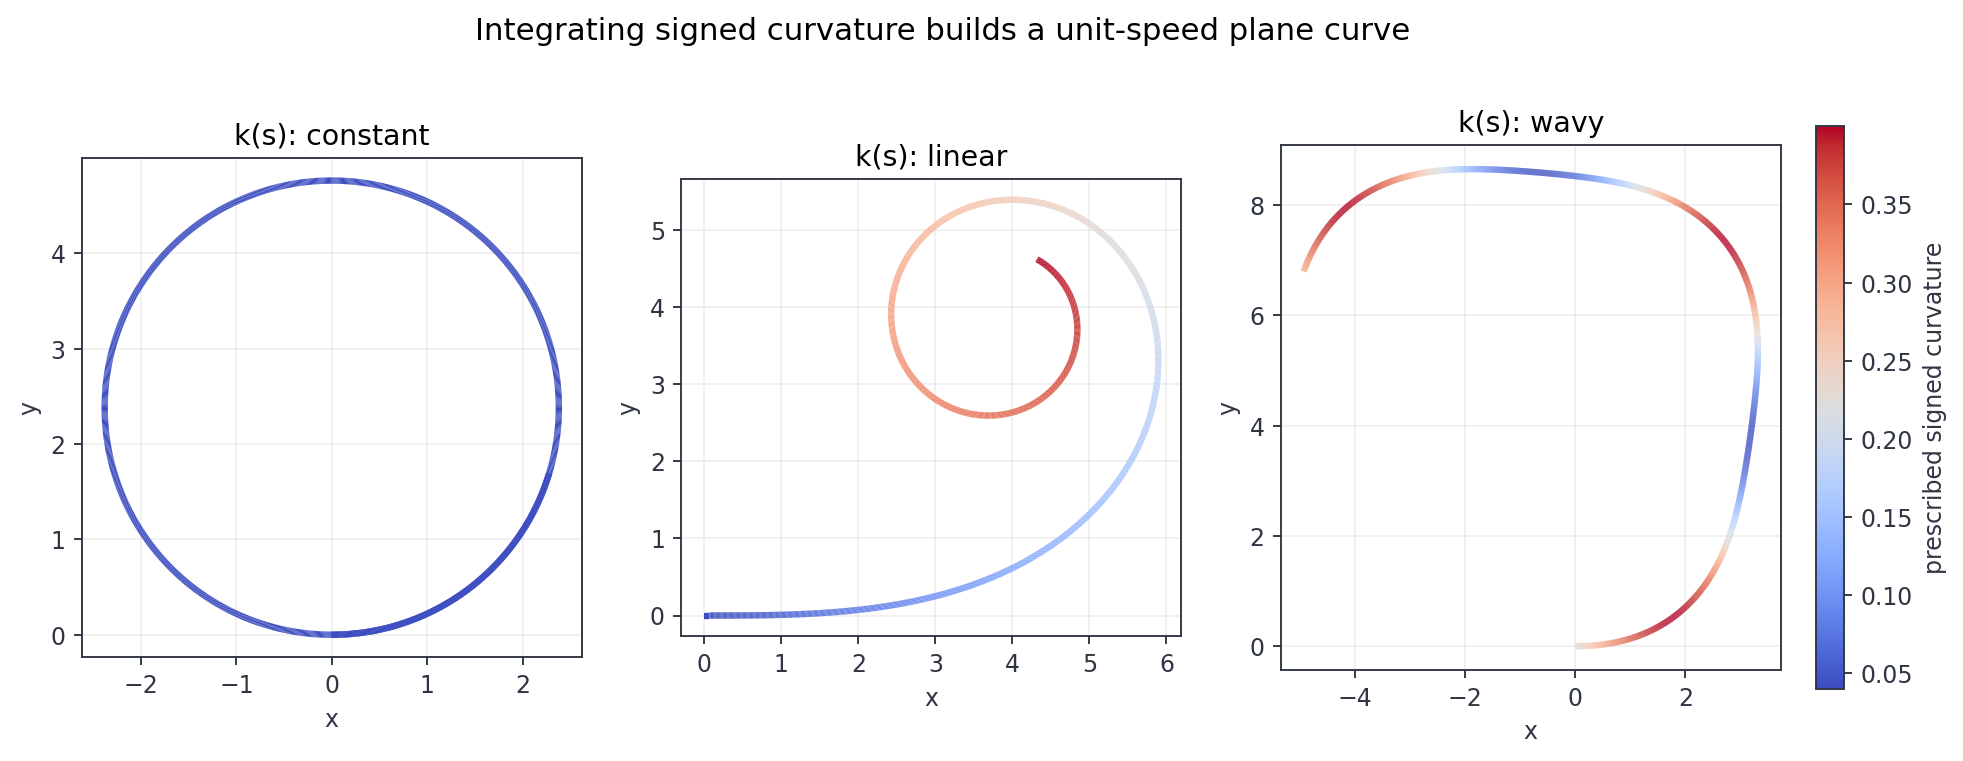

,input,speed_mean,speed_max_error,curvature_rmse,total_turning_over_2pi,end_to_end_distance
0,constant,0.999994,0.000006,7.823763e-07,1.203211,2.837696
1,linear,0.999990,0.000030,3.668162e-06,1.418071,6.327291
2,wavy,0.999998,0.000005,5.710318e-06,0.694894,8.395608


In [11]:
def reconstruct_from_signed_curvature(s_values, k_values):
    phi_values = cumulative_trapezoid(k_values, s_values)
    tangent_values = np.column_stack([np.cos(phi_values), np.sin(phi_values)])
    x_values = cumulative_trapezoid(tangent_values[:, 0], s_values)
    y_values = cumulative_trapezoid(tangent_values[:, 1], s_values)
    return np.column_stack([x_values, y_values]), phi_values


s_lab = np.linspace(0.0, 18.0, 1600)
lab_specs = [
    ("constant", np.full_like(s_lab, 0.42)),
    ("linear", 0.055 * s_lab),
    ("wavy", 0.22 + 0.18 * np.sin(0.85 * s_lab)),
]

lab_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
for ax, (label, k_input) in zip(axes, lab_specs):
    curve, phi_values = reconstruct_from_signed_curvature(s_lab, k_input)
    measured_speed = speed(curve, s_lab)
    measured_k = signed_curvature_2d(curve, s_lab)
    trim = slice(35, -35)
    error = measured_k[trim] - k_input[trim]
    collection = line_collection_by_value(curve[:, 0], curve[:, 1], k_input, linewidth=2.7)
    ax.add_collection(collection)
    ax.autoscale()
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"k(s): {label}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.18)
    lab_rows.append({
        "input": label,
        "speed_mean": float(np.mean(measured_speed[trim])),
        "speed_max_error": float(np.max(np.abs(measured_speed[trim] - 1.0))),
        "curvature_rmse": float(np.sqrt(np.mean(error**2))),
        "total_turning_over_2pi": float((phi_values[-1] - phi_values[0]) / (2 * np.pi)),
        "end_to_end_distance": float(np.linalg.norm(curve[-1] - curve[0])),
    })
fig.colorbar(collection, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label="prescribed signed curvature")
fig.suptitle("Integrating signed curvature builds a unit-speed plane curve", y=1.03, fontsize=13)
lab_figure = save_figure(fig, "curvature-reconstruction-lab.png")
lab_table = pd.DataFrame(lab_rows)
lab_path_json = write_check("applied-lab-summary.json", {"rows": lab_rows})
display_artifact(lab_figure, width=980)
lab_table


## Final Sanity Checks

The final cell checks the chapter-specific promises: generated artifacts exist, symbolic formulas simplify to the expected identities, numerical residuals are small, and the notebook no longer calls the old generic visual-build path.


In [12]:
artifact_paths = [
    source_path,
    storyboard_path,
    symbolic_path,
    curvature_path_json,
    turning_path_json,
    osculating_path_json,
    helix_path_json,
    fs_path_json,
    lab_path_json,
    curvature_figure,
    signed_figure,
    osculating_figure,
    torsion_figure,
    frame_figure,
    lab_figure,
    interactive_path,
]
checked_artifacts = [assert_artifact(path, min_bytes=(128 if Path(path).suffix.lower() == ".json" else 900)) for path in artifact_paths]

notebook_text = CHAPTER_NOTEBOOK.read_text(encoding="utf-8")
forbidden_helper = "build_" + "unit_visuals"
assert forbidden_helper not in notebook_text
assert symbolic_checks["circle_reparameterization"]["equals_1_over_R"]
assert symbolic_checks["helix_formulas"]["curvature_matches"]
assert symbolic_checks["helix_formulas"]["torsion_matches"]
assert curvature_check["max_error_plain_from_1_over_R"] < 2e-3
assert curvature_check["max_error_reparameterized_from_1_over_R"] < 3e-2
assert turning_check["max_abs_dphi_ds_minus_signed_curvature"] < 8e-3
assert abs(turning_check["ellipse_turning_number"] - 1.0) < 5e-3
assert osculating_check["converges_as_delta_shrinks"]
assert helix_check["max_abs_curvature_residual"] < 2e-3
assert helix_check["max_abs_torsion_residual"] < 4e-3
assert helix_check["plane_circle_max_abs_torsion"] < 1e-8
assert fs_check["symbolic_residuals_zero"]
assert fs_check["skew_symmetric_matrix_residual_zero"]
assert fs_check["max_abs_T_equation_residual"] < 1e-4
assert fs_check["max_abs_N_equation_residual"] < 1e-4
assert fs_check["max_abs_B_equation_residual"] < 1e-4
assert fs_check["max_gram_residual"] < 1e-12
assert max(row["speed_max_error"] for row in lab_rows) < 2e-3
assert max(row["curvature_rmse"] for row in lab_rows) < 2.5e-3

final_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "artifact_count": len(checked_artifacts),
    "artifact_paths": [relative_to_book(path) for path in checked_artifacts],
    "checks": {
        "generic_visual_helper_absent": True,
        "symbolic_circle_curvature": symbolic_checks["circle_reparameterization"]["curvature"],
        "symbolic_helix_curvature": symbolic_checks["helix_formulas"]["curvature"],
        "symbolic_helix_torsion": symbolic_checks["helix_formulas"]["torsion"],
        "curvature_invariance_max_error": curvature_check["max_error_reparameterized_from_1_over_R"],
        "turning_residual_max": turning_check["max_abs_dphi_ds_minus_signed_curvature"],
        "ellipse_turning_number": turning_check["ellipse_turning_number"],
        "osculating_error_ratio_first_to_last": osculating_check["error_ratio_first_to_last"],
        "helix_torsion_residual_max": helix_check["max_abs_torsion_residual"],
        "frenet_serret_residual_max": max(fs_check["max_abs_T_equation_residual"], fs_check["max_abs_N_equation_residual"], fs_check["max_abs_B_equation_residual"]),
        "lab_max_speed_error": max(row["speed_max_error"] for row in lab_rows),
        "lab_max_curvature_rmse": max(row["curvature_rmse"] for row in lab_rows),
    },
}
final_sanity_path = write_check("final-sanity.json", final_sanity)
notebook_sanity_path = write_check("notebook-sanity.json", final_sanity)
summary_artifacts = [assert_artifact(final_sanity_path, min_bytes=400), assert_artifact(notebook_sanity_path, min_bytes=400)]
final_sanity["artifact_count"] = len(checked_artifacts) + len(summary_artifacts)
final_sanity["artifact_paths"] = [relative_to_book(path) for path in checked_artifacts + summary_artifacts]
final_sanity_path = write_check("final-sanity.json", final_sanity)
notebook_sanity_path = write_check("notebook-sanity.json", final_sanity)
assert_artifact(final_sanity_path, min_bytes=400)
assert_artifact(notebook_sanity_path, min_bytes=400)
final_sanity


{'unit': 'chapter-02',
 'source_span': {'title': 'How much does a curve curve?',
  'book': 'Andrew Pressley, Elementary Differential Geometry, Second Edition',
  'printed_pages': '29-54',
  'pdf_pages': '38-63',
  'sections': '2.1-2.3',
  'orientation_only': True},
 'artifact_count': 18,
 'artifact_paths': ['artifacts/chapter-02/checks/source-span.json',
  'artifacts/chapter-02/checks/visual-storyboard.json',
  'artifacts/chapter-02/checks/curvature-formula-symbolic.json',
  'artifacts/chapter-02/checks/curvature-invariance-checks.json',
  'artifacts/chapter-02/checks/signed-curvature-turning-checks.json',
  'artifacts/chapter-02/checks/osculating-evolute-checks.json',
  'artifacts/chapter-02/checks/helix-torsion-checks.json',
  'artifacts/chapter-02/checks/frenet-serret-residuals.json',
  'artifacts/chapter-02/checks/applied-lab-summary.json',
  'artifacts/chapter-02/figures/curvature-chapter-02.png',
  'artifacts/chapter-02/figures/signed-curvature-turning.png',
  'artifacts/chapter-

## Takeaways

- Curvature is local second-order geometry, not just visual bend in a plotted trace.
- The arbitrary-parameter formulas are speed-corrected formulas: they attach `kappa` and `tau` to the curve, not to the clock used to traverse it.
- Signed curvature is stronger than unsigned curvature because it keeps orientation and tangent turning.
- Osculating circles convert curvature into a concrete center and radius; the path of those centers is the evolute.
- Torsion is the space-curve ingredient that plane curves do not need: zero torsion is the computational signal of planarity when curvature is nonzero.
- The Frenet-Serret equations are a frame-preservation system. Their skew-symmetric matrix is why orthonormality survives as the frame moves.
